In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
#| echo: false
#| include: false
packages = ["SymPyPythonCall", "Plots", "LaTeXStrings", "QuadGK"]

4-element Vector{String}:
 "SymPyPythonCall"
 "Plots"
 "LaTeXStrings"
 "QuadGK"

In [3]:
#| echo: false
#| include: false
using Plots
# Plots y Makie generan además una representación text/html con la imagen en base64
# en una sola línea; con figuras grandes esa línea desborda la pila del conversor
# de Quarto a Markdown. La desactivamos y dejamos solo image/png.
Base.showable(::MIME"text/html", ::Plots.Plot) = false

In [4]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("![](https://img.shields.io/badge/Julia-$(v)-9558B2?logo=julia)")

![](https://img.shields.io/badge/Julia-1.12.6-9558B2?logo=julia)


In [5]:
#| echo: false
using Markdown
v = string(VERSION)
Markdown.parse("**Versión de Julia:** $(v)")

**Versión de Julia:** 1.12.6


In [6]:
#| echo: false
#| include: false
import Pkg
active_project = Base.active_project()
global_env = joinpath(homedir(), ".julia", "environments", "v$(VERSION.major).$(VERSION.minor)", "Project.toml")
Pkg.activate(global_env)

  Activating project at `~/.julia/environments/v1.12`


In [7]:
#| echo: false
Pkg.status(packages)

Status `~/.julia/environments/v1.12/Project.toml`
  [b964fa9f] LaTeXStrings v1.4.0
  [91a5bcdd] Plots v1.41.6
  [1fd47b50] QuadGK v2.11.3
  [bc8888f7] SymPyPythonCall v0.5.1


In [8]:
#| echo: false
#| include: false
#Pkg.activate(active_project)

In [9]:
using SymPyPythonCall
@syms x xi a b
# Continuidad en x = xi:  a*xi = b*(1 - xi)
# Salto de la derivada:   (-b) - a = -1
coef = solve([a*xi - b*(1 - xi), -b - a + 1], [a, b])

Dict{Sym{PythonCall.Py}, Sym{PythonCall.Py}} with 2 entries:
  b => xi
  a => 1 - xi

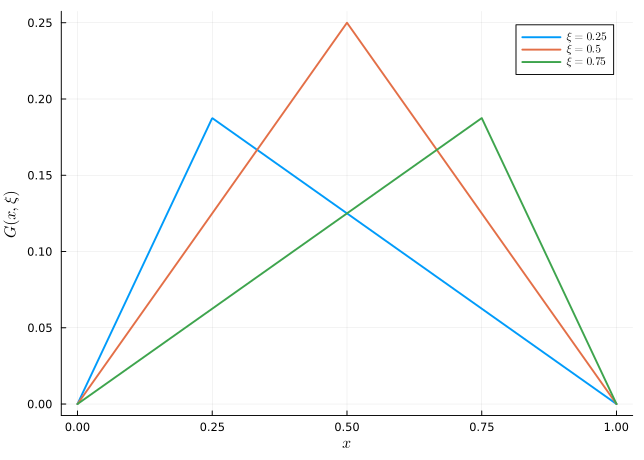

In [10]:
using Plots, LaTeXStrings
G(x, ξ) = x <= ξ ? x*(1-ξ) : ξ*(1-x)
ξs = [0.25, 0.5, 0.75]
plt = plot(xlab = L"x", ylab = L"G(x,\xi)")
for ξ in ξs
    plot!(plt, xx -> G(xx, ξ), 0, 1, lw = 2, label = L"\xi=%$ξ")
end
plt

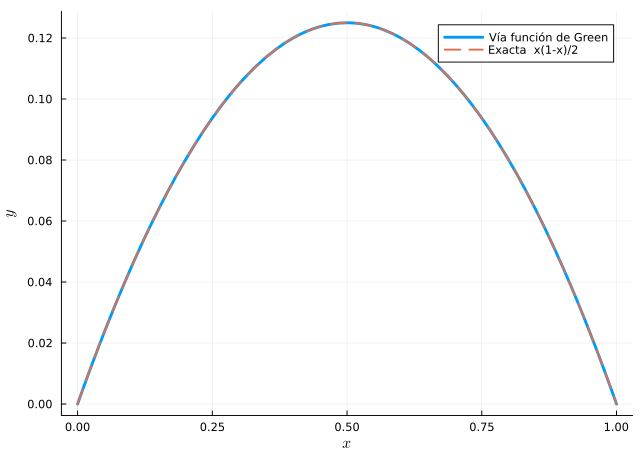

In [11]:
using QuadGK
y(x) = quadgk(ξ -> G(x, ξ) * 1.0, 0, 1)[1]
yexacta(x) = x*(1-x)/2
plot(y, 0, 1, lw = 3, label = "Vía función de Green",
    xlab = L"x", ylab = L"y")
plot!(yexacta, 0, 1, lw = 2, ls = :dash, label = "Exacta  x(1-x)/2")

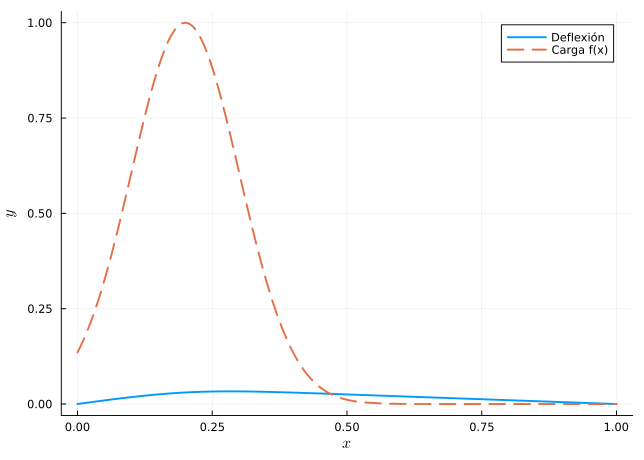

In [12]:
f(x) = exp(-50*(x - 0.2)^2)
yG(x) = quadgk(ξ -> G(x, ξ) * f(ξ), 0, 1)[1]
plot(yG, 0, 1, lw = 2, label = "Deflexión", xlab = L"x", ylab = L"y")
plot!(f, 0, 1, lw = 2, ls = :dash, label = "Carga f(x)")

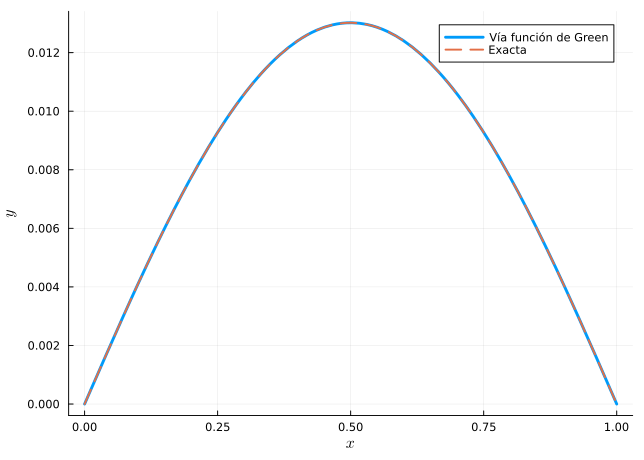

In [13]:
using QuadGK, Plots, LaTeXStrings
function Gviga(x, ξ)
    if x <= ξ
        (1-ξ)*x/6 * ((2-ξ)*ξ - x^2)
    else
        (1-x)*ξ/6 * ((2-x)*x - ξ^2)
    end
end

yG(x) = quadgk(ξ -> Gviga(x, ξ), 0, 1)[1]
yexacta(x) = (x^4 - 2x^3 + x)/24
plot(yG, 0, 1, lw = 3, label = "Vía función de Green", xlab = L"x", ylab = L"y")
plot!(yexacta, 0, 1, lw = 2, ls = :dash, label = "Exacta")

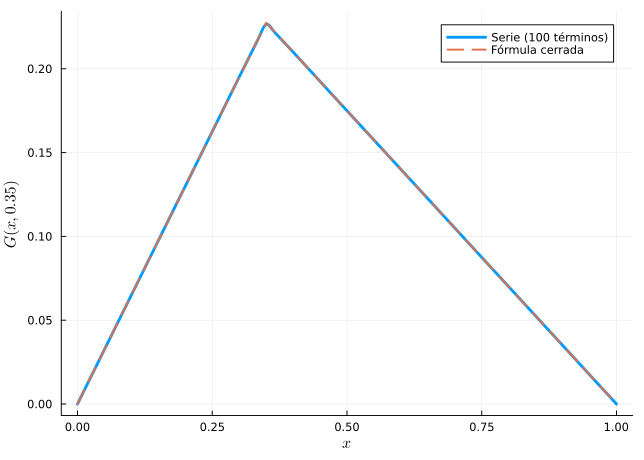

In [14]:
using Plots, LaTeXStrings
Gserie(x, ξ; N = 100) = sum(2*sin(n*π*x)*sin(n*π*ξ)/(n*π)^2 for n in 1:N)
Gexacta(x, ξ) = x <= ξ ? x*(1-ξ) : ξ*(1-x)
ξ = 0.35
plot(x -> Gserie(x, ξ), 0, 1, lw = 3, label = "Serie (100 términos)",
    xlab = L"x", ylab = L"G(x,0.35)")
plot!(x -> Gexacta(x, ξ), 0, 1, lw = 2, ls = :dash, label = "Fórmula cerrada")

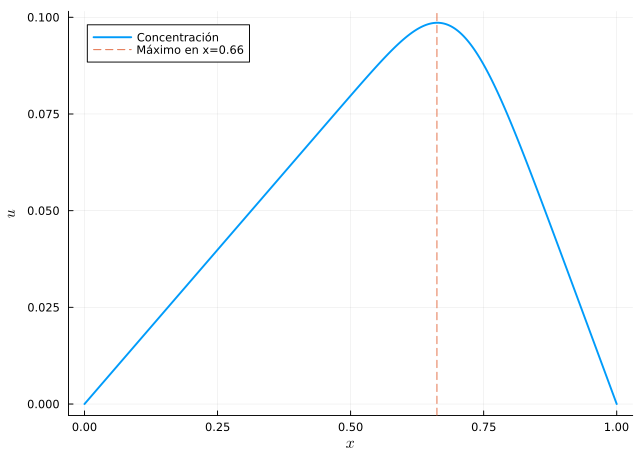

In [15]:
using QuadGK, Plots, LaTeXStrings
G(x, ξ) = x <= ξ ? x*(1-ξ) : ξ*(1-x)
f(x) = 3*exp(-100*(x - 0.7)^2)
u(x) = quadgk(ξ -> G(x, ξ)*f(ξ), 0, 1)[1]
xs = range(0, 1, length = 300)
us = u.(xs)
xmax = xs[argmax(us)]
plot(xs, us, lw = 2, label = "Concentración", xlab = L"x", ylab = L"u")
vline!([xmax], ls = :dash, label = "Máximo en x=$(round(xmax,digits=2))")